# Customer Risk Clustering using KMeans

Task:
Identify Customer Risk Cluster using PCA and KMeans clustering
_________________________________________________________________
Scenario:
A Bank wants to:
1. discover hidden groups of credit card customers.
2. Identify High risk cluster/segments likely to default.
3. Design different credit strategies for each cluster/segments
_________________________________________________________________

Part 1:-----------------------------------

- Data Understanding and Cleaning
1. load dataset.
2. Check missing values and handle them.

Part 2:-----------------------------------

1. Use Elbow method to find k clusters.
2. fit Kmeans on k clusters.

Part 3:------------------------------------

1. For each cluster, compute:
	- Average credit limit.
	- average bill amount.

2. Label clusters as :
	- High value (safe customers)
	- Moderate customers.
	- High Risk customers

Identify which cluster needs risk monitoring

## Part 1 – Data Loading and Cleaning

In [10]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('UCI_Credit_Card.csv')

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [11]:
df.shape

(30000, 25)

In [12]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

## Part 2 – PCA and KMeans Clustering

In [13]:
from sklearn.preprocessing import StandardScaler

df_clean = df.drop(columns=['ID'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])
pca_df.head()

,PC1,PC2
0,-1.800973,1.270393
1,-0.671428,2.406269
2,-0.858546,0.969766
3,-0.210006,0.706131
4,-0.860082,-0.002982


### Elbow Method to Find Optimal K

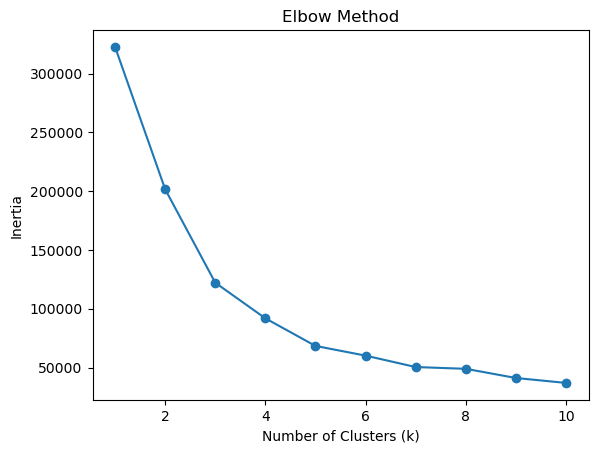

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(pca_df)

df['Cluster'] = clusters

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,Cluster
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,3
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,3
2,3,90000.0,2,2,2,34,0,0,0,0,...,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,3
3,4,50000.0,2,2,1,37,0,0,0,0,...,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,3
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,3


## Part 3 – Cluster Analysis

In [17]:
# Compute average credit limit and bill amount
cluster_summary = df.groupby('Cluster').agg({
    'LIMIT_BAL':'mean',
    'BILL_AMT1':'mean'
}).rename(columns={
    'LIMIT_BAL':'Avg_Credit_Limit',
    'BILL_AMT1':'Avg_Bill_Amount'
})

cluster_summary

,Avg_Credit_Limit,Avg_Bill_Amount
Cluster,,
0,372381.011673,295824.216926
1,231559.550562,135418.262022
2,72144.537815,37741.435966
3,108559.141520,35475.487897
4,224098.109909,8523.696821


## Cluster Interpretation

- **High Value Customers** → High credit limit, low bill pressure.
- **Moderate Customers** → Medium credit usage and payments.
- **High Risk Customers** → Low credit limit but high bill amounts or frequent late payments.

**Cluster with highest bill amount and lowest repayment behaviour should be monitored for risk.**